In [3]:
# This notebook creates spatial distribution maps of energy poverty
import numpy as np
import pandas as pd

df= pd.read_parquet(r"MYANMAR\DATA\4.MM_MASTER_DATASET.parquet", engine="pyarrow")


In [5]:
region_lookup = {
1: "Kachin",
2: "Kayah",
3: "Kayin",
4: "Chin",
5: "Sagaing",
6: "Taninthayi",
7: "Bago",
8: "Magway",
9: "Mandalay",
10: "Mon",
11: "Rakhine",
12: "Yangon",
13: "Shan",
14: "Ayeyarwaddy",
15: "NayPyitaw"
}

df["region_name"] = df["hv024RegionDivision"].map(region_lookup)

df[["hv024RegionDivision","region_name"]].head(20)

,hv024RegionDivision,region_name
0,8,Magway
1,8,Magway
2,8,Magway
3,8,Magway
4,8,Magway
5,8,Magway
6,12,Yangon
7,12,Yangon
8,12,Yangon
9,12,Yangon


In [7]:
region_headcount = (
    df.groupby("region_name")
      .apply(lambda x: (x["EnergyPoor"] * x["weight"]).sum() / x["weight"].sum() * 100)
      .reset_index(name="headcount_pct")
)

region_headcount["headcount_pct"] = region_headcount["headcount_pct"].round(0)

region_headcount

C:\Users\ayeei\AppData\Local\Temp\ipykernel_31172\276070815.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["EnergyPoor"] * x["weight"]).sum() / x["weight"].sum() * 100)


,region_name,headcount_pct
0,Ayeyarwaddy,94.0
1,Bago,81.0
2,Chin,92.0
3,Kachin,84.0
4,Kayah,73.0
5,Kayin,78.0
6,Magway,87.0
7,Mandalay,69.0
8,Mon,74.0
9,NayPyitaw,66.0


In [33]:
import geopandas as gpd

mm_map = gpd.read_file(
    r"MYANMAR/SHPS/sdr_subnational_boundaries.shp"
)


In [35]:
mm_gdf = mm_map.merge(
    region_headcount,
    left_on="REGNAME",
    right_on="region_name",
    how="left"
)

mm_gdf[["REGNAME", "headcount_pct"]]

,REGNAME,headcount_pct
0,Ayeyarwaddy,94.0
1,Bago,81.0
2,Chin,92.0
3,Kachin,84.0
4,Kayah,73.0
5,Kayin,78.0
6,Magway,87.0
7,Mandalay,69.0
8,Mon,74.0
9,NayPyitaw,66.0


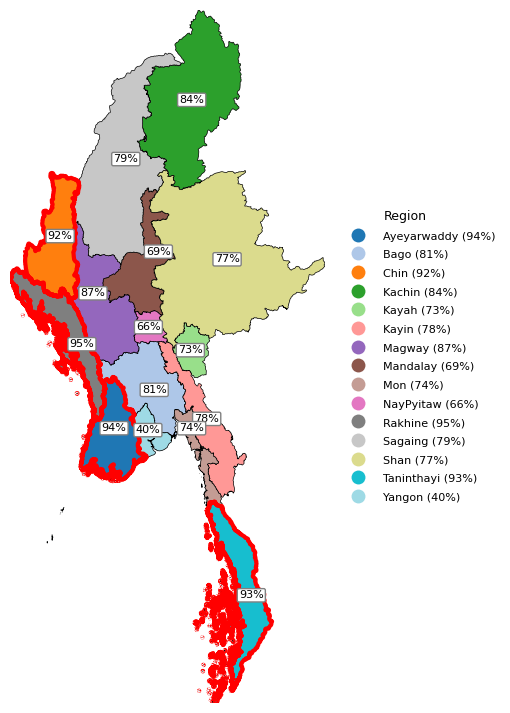

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 9))

# Plot base map
mm_gdf.plot(
    column="REGNAME",
    cmap="tab20",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

q75 = mm_gdf["headcount_pct"].quantile(0.75)
top_quartile = mm_gdf[mm_gdf["headcount_pct"] >= q75]

top_quartile.boundary.plot(
    ax=ax,
    edgecolor="red",
    linewidth=3
)

# create region -> headcount lookup
headcount_lookup = dict(zip(mm_gdf["REGNAME"], mm_gdf["headcount_pct"]))

# add % labels inside regions
for idx, row in mm_gdf.iterrows():
    point = row.geometry.representative_point()
    ax.text(
        point.x,
        point.y,
        f"{int(row['headcount_pct'])}%",
        ha="center",
        va="center",
        fontsize=8,
        bbox=dict(facecolor="white", edgecolor="gray", boxstyle="round,pad=0.15")
    )

ax.axis("off")
ax.margins(0)

# update legend
legend = ax.get_legend()
legend.set_title("Region")
legend.get_title().set_position((-14, 0))

for text in legend.get_texts():
    region = text.get_text()
    headcount = headcount_lookup.get(region)
    if pd.notna(headcount):
        text.set_text(f"{region} ({int(headcount)}%)")
    else:
        text.set_text(f"{region} (No data)")

legend.set_bbox_to_anchor((1.02, 0.5))
legend._loc = 6
legend.get_frame().set_linewidth(0)
legend.get_frame().set_edgecolor('none')

# font sizes
for text in legend.get_texts():
    text.set_fontsize(8)
legend.get_title().set_fontsize(9)

# tighten map bounds
xmin, ymin, xmax, ymax = mm_gdf.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.margins(0)

# Draw and save
fig.canvas.draw()
plt.savefig(
    r"MYANMAR/MAP/Figure1_myanmar_energy_poverty_headcount.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()